# Thank You, Warriors!

In [1]:
import pandas as pd
from nba_api.stats.endpoints import leaguegamelog
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
warriors_id = 1610612744
season = '2025-26'
season_type = 'Regular Season'

## Percent Played Table

In [3]:
team_games = leaguegamelog.LeagueGameLog(
    season=season,
    season_type_all_star=season_type,
    player_or_team_abbreviation='T'
).get_data_frames()[0]

team_games = team_games[team_games['TEAM_ID'] == warriors_id].copy()
team_games['GAME_DATE'] = pd.to_datetime(team_games['GAME_DATE'])
team_games = team_games.sort_values('GAME_DATE').reset_index(drop=True)

total_games = team_games['GAME_ID'].nunique()
print(total_games)

82


We are missing two games here at the end.

In [53]:
team_games[['GAME_DATE']].tail(5)

,GAME_DATE
77,2026-04-05
78,2026-04-07
79,2026-04-09
80,2026-04-10
81,2026-04-12


In [4]:
player_games = leaguegamelog.LeagueGameLog(
    season=season,
    season_type_all_star=season_type,
    player_or_team_abbreviation='P'
).get_data_frames()[0]

player_games = player_games[player_games['TEAM_ID'] == warriors_id].copy()
player_games['GAME_DATE'] = pd.to_datetime(player_games['GAME_DATE'])
player_games = player_games.sort_values(['PLAYER_NAME', 'GAME_DATE']).reset_index(drop=True)

In [5]:
player_summary = (
    player_games
    .groupby(['PLAYER_ID', 'PLAYER_NAME'])
    .agg(
        first_game=('GAME_DATE', 'min'),
        last_game=('GAME_DATE', 'max'),
        games_played=('GAME_ID', 'nunique')
    )
    .reset_index()
)

In [6]:
team_dates = team_games['GAME_DATE']

def count_games_possible(first_game, last_game, team_dates):
    return ((team_dates >= first_game) & (team_dates <= last_game)).sum()

player_summary['games_possible'] = player_summary.apply(
    lambda row: count_games_possible(row['first_game'], row['last_game'], team_dates),
    axis=1
)

In [7]:
player_summary['pct_played_possible'] = (
    player_summary['games_played'] / player_summary['games_possible'] * 100
)

player_summary['pct_played_total'] = (
    player_summary['games_played'] / total_games * 100
)

player_summary['pct_missed_total'] = (
    100 - player_summary['pct_played_total']
)

In [8]:
player_summary['pct_played_possible'] = player_summary['pct_played_possible'].round(1)
player_summary['pct_played_total'] = player_summary['pct_played_total'].round(1)
player_summary['pct_missed_total'] = player_summary['pct_missed_total'].round(1)

player_summary = player_summary[
    [
        'PLAYER_NAME',
        'first_game',
        'last_game',
        'games_played',
        'games_possible',
        'pct_played_possible',
        'pct_played_total',
        'pct_missed_total'
    ]
].sort_values(['pct_played_total', 'games_played'], ascending=False).reset_index(drop=True)

player_summary.head(20)

,PLAYER_NAME,first_game,last_game,games_played,games_possible,pct_played_possible,pct_played_total,pct_missed_total
0,Brandin Podziemski,2025-10-21,2026-04-12,82,82,100.0,100.0,0.0
1,Gary Payton II,2025-10-21,2026-04-12,73,82,89.0,89.0,11.0
2,Will Richard,2025-10-21,2026-04-12,69,82,84.1,84.1,15.9
3,Draymond Green,2025-10-21,2026-04-10,68,81,84.0,82.9,17.1
4,Gui Santos,2025-10-21,2026-04-12,68,82,82.9,82.9,17.1
5,Quinten Post,2025-10-21,2026-03-29,67,75,89.3,81.7,18.3
6,Pat Spencer,2025-10-24,2026-04-12,66,80,82.5,80.5,19.5
7,Moses Moody,2025-10-24,2026-03-23,60,70,85.7,73.2,26.8
8,De'Anthony Melton,2025-12-04,2026-04-12,49,60,81.7,59.8,40.2
9,Al Horford,2025-10-21,2026-04-12,45,82,54.9,54.9,45.1


In [9]:
player_summary[player_summary['PLAYER_NAME'] == 'Stephen Curry']

,PLAYER_NAME,first_game,last_game,games_played,games_possible,pct_played_possible,pct_played_total,pct_missed_total
11,Stephen Curry,2025-10-21,2026-04-12,43,82,52.4,52.4,47.6


In [10]:
player_summary[player_summary['PLAYER_NAME'] == 'Gui Santos']

,PLAYER_NAME,first_game,last_game,games_played,games_possible,pct_played_possible,pct_played_total,pct_missed_total
4,Gui Santos,2025-10-21,2026-04-12,68,82,82.9,82.9,17.1


In [11]:
player_summary[player_summary['PLAYER_NAME'] == 'Gary Payton II']

,PLAYER_NAME,first_game,last_game,games_played,games_possible,pct_played_possible,pct_played_total,pct_missed_total
1,Gary Payton II,2025-10-21,2026-04-12,73,82,89.0,89.0,11.0


Draymond's percent is same as Gui. This is wrong because last game should be 2026-04-12.

In [12]:
player_summary[player_summary['PLAYER_NAME'] == 'Draymond Green']

,PLAYER_NAME,first_game,last_game,games_played,games_possible,pct_played_possible,pct_played_total,pct_missed_total
3,Draymond Green,2025-10-21,2026-04-10,68,81,84.0,82.9,17.1


In [13]:
player_summary[player_summary['PLAYER_NAME'] == 'Moses Moody']

,PLAYER_NAME,first_game,last_game,games_played,games_possible,pct_played_possible,pct_played_total,pct_missed_total
7,Moses Moody,2025-10-24,2026-03-23,60,70,85.7,73.2,26.8


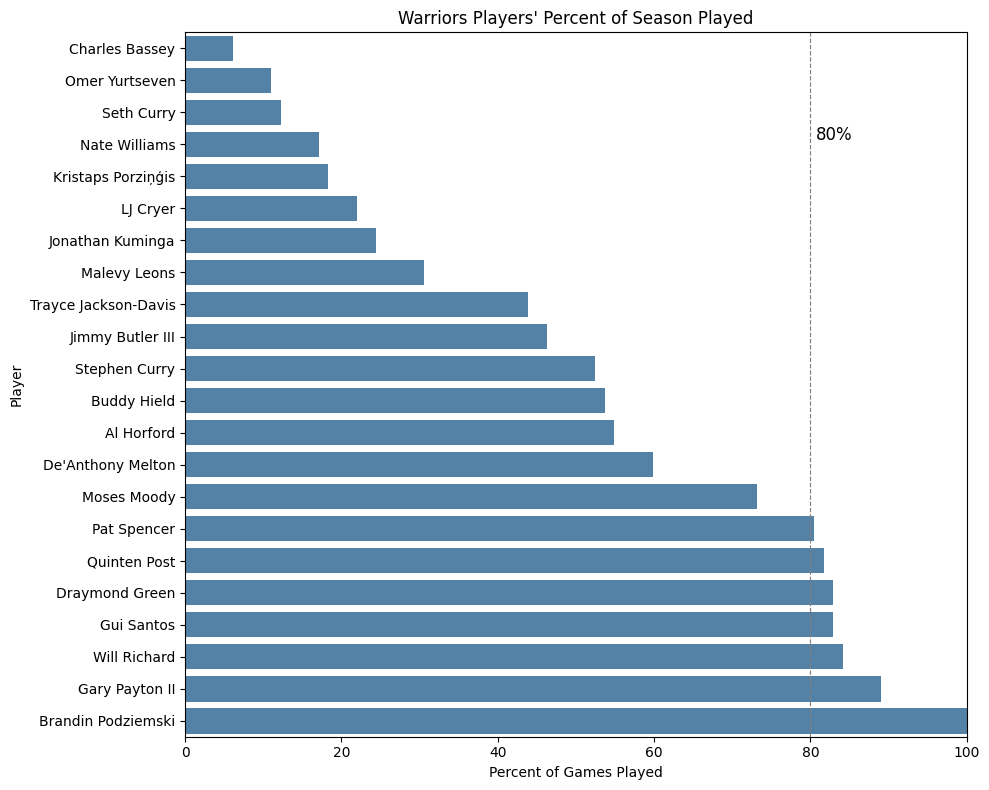

In [14]:
plt.figure(figsize=(10, 8))

plot_df = player_summary.sort_values('pct_played_total', ascending=True)

   
sns.barplot(
    data=plot_df,
    x='pct_played_total',
    y='PLAYER_NAME',
    color='steelblue'
)

plt.axvline(80, linewidth=0.85, linestyle='--', color='gray', zorder=1)
plt.text(
        83,
        3,
        '80%',
        rotation=0,
        va='bottom',
        ha='center',
        fontsize=12,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1),
        zorder=3   # keep text above everything
    )

plt.xlabel('Percent of Games Played')
plt.ylabel('Player')
plt.title('Warriors Players\' Percent of Season Played')

plt.xlim(0, 100)

plt.tight_layout()
plt.savefig('002_percent_games_played.png', dpi=300, bbox_inches='tight')
plt.show()

## Baseline Roster Over Time

In [15]:
initial_games = player_games[player_games['GAME_DATE'] <= player_games['GAME_DATE'].min() + pd.Timedelta(days=10)]

original_players = set(initial_games['PLAYER_ID'].unique())

In [16]:
def count_original_players(df, original_set):
    return df['PLAYER_ID'].isin(original_set).sum()

erosion = (
    player_games
    .groupby(['GAME_ID', 'GAME_DATE'])
    .apply(lambda x: count_original_players(x, original_players))
    .reset_index(name='original_players_active')
)

C:\Users\ehze\AppData\Local\Temp\ipykernel_38024\724831859.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  player_games


In [17]:
erosion['GAME_DATE'] = pd.to_datetime(erosion['GAME_DATE'])
erosion = erosion.sort_values('GAME_DATE').reset_index(drop=True)

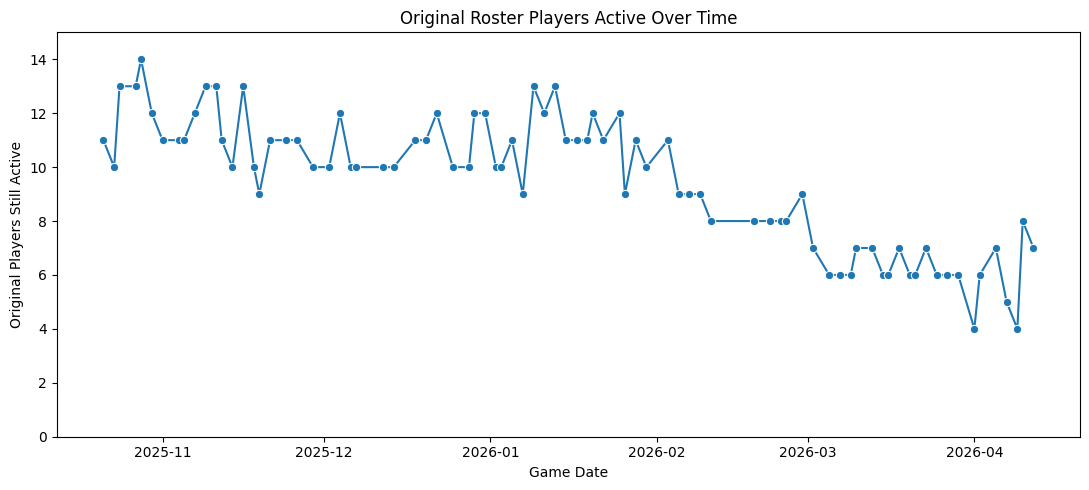

In [18]:
plt.figure(figsize=(11, 5))

sns.lineplot(
    data=erosion,
    x='GAME_DATE',
    y='original_players_active',
    marker='o'
)

plt.title('Original Roster Players Active Over Time')
plt.xlabel('Game Date')
plt.ylabel('Original Players Still Active')

plt.ylim(0, 15)  # 👈 this line

plt.tight_layout()
plt.savefig('002_original_roster_count_raw.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
import pandas as pd

events = pd.DataFrame({
    'date': [
        '2026-01-19',  # Jimmy injury
        '2026-01-30',  # Steph injury
        '2026-02-05',  # Trade (JK + Buddy + Trayce)
        '2026-03-23'
    ],
    'label': [
        'Butler (ACL tear)',
        'Steph (Knee syndrome)',
        'JK + Buddy + TJD (Trade)',
        'Moody (Knee tear)'
    ],
    'type': [
        'injury',
        'injury',
        'trade',
        'injury'
    ]
})

events['date'] = pd.to_datetime(events['date'])

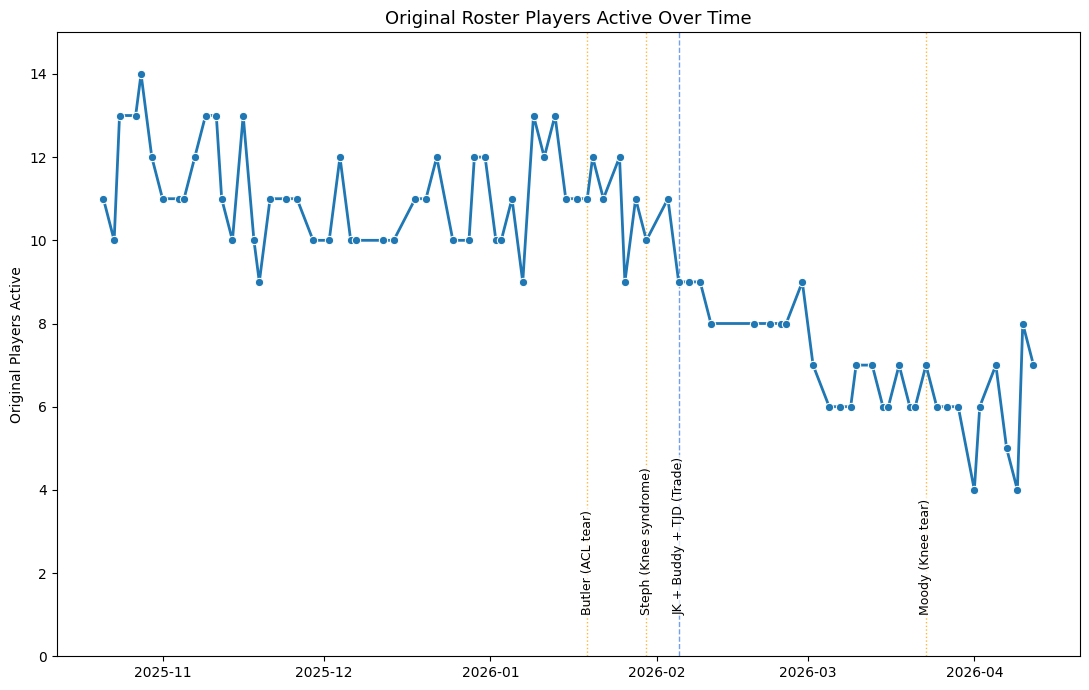

In [20]:
plt.figure(figsize=(11, 7))

# vertical lines FIRST (or use low zorder)
y_positions = [1.0, 1.0, 1.0, 1.0]

for i, (_, row) in enumerate(events.iterrows()):
    
    if row['type'] == 'trade':
        color = 'cornflowerblue'
        lw = 1
        ls = '--'
        alpha = 0.9
    else:
        color = 'orange'
        lw = 1
        ls = ':'
        alpha = 0.8

    plt.axvline(
        row['date'],
        color=color,
        linewidth=lw,
        linestyle=ls,
        alpha=alpha,
        zorder=1   # push behind
    )
    
    plt.text(
        row['date'],
        y_positions[i],
        row['label'],
        rotation=90,
        va='bottom',
        ha='center',
        fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1),
        zorder=3   # keep text above everything
    )

# main line LAST (or higher zorder)
sns.lineplot(
    data=erosion,
    x='GAME_DATE',
    y='original_players_active',
    marker='o',
    linewidth=2,
    zorder=2   # above vertical lines
)

plt.title('Original Roster Players Active Over Time', fontsize=13)
plt.xlabel('')
plt.ylabel('Original Players Active')

plt.ylim(0, 15)

plt.tight_layout()
plt.savefig('002_original_roster_count.png', dpi=300, bbox_inches='tight')
plt.show()

## Pre-During-Post Team Stats

In [21]:
team_games_summary = (
    player_games
    .groupby('GAME_ID')
    .agg({
        'PTS': 'sum',
        'FG3M': 'sum',
        'AST': 'sum',
        'GAME_DATE': 'first'
    })
    .reset_index()
)

team_games_summary['GAME_DATE'] = pd.to_datetime(team_games_summary['GAME_DATE'])

In [22]:
pre_start = None
pre_end = '2026-01-29'

injury_start = '2026-01-30'
injury_end = '2026-04-04'

post_start = '2026-04-05'
post_end = erosion['GAME_DATE'].max()   # uses your actual last date

In [23]:
post_end

Timestamp('2026-04-12 00:00:00')

In [24]:
def summarize_team(df, start, end):
    
    temp = df.copy()
    
    if start is not None:
        temp = temp[temp['GAME_DATE'] >= pd.to_datetime(start)]
    
    if end is not None:
        temp = temp[temp['GAME_DATE'] <= pd.to_datetime(end)]
    
    return pd.Series({
        'PPG': temp['PTS'].mean(),
        '3PM': temp['FG3M'].mean(),
        'AST': temp['AST'].mean(),
        'Games': len(temp)
    })

In [25]:
team_summary = pd.concat([
    summarize_team(team_games_summary, None, pre_end),
    summarize_team(team_games_summary, injury_start, injury_end),
    summarize_team(team_games_summary, post_start, post_end)
], axis=1)

team_summary.columns = ['Pre', 'Injury', 'Post']

team_summary = team_summary.round(1)
team_summary

,Pre,Injury,Post
PPG,116.5,111.9,111.4
3PM,16.3,15.1,13.0
AST,28.9,29.1,27.8
Games,49.0,28.0,5.0


In [26]:
team_summary = team_summary.T.reset_index()
team_summary.columns = ['Period', 'PPG', '3PM', 'AST', 'Games']
team_summary

,Period,PPG,3PM,AST,Games
0,Pre,116.5,16.3,28.9,49.0
1,Injury,111.9,15.1,29.1,28.0
2,Post,111.4,13.0,27.8,5.0


In [27]:
team_summary.to_csv('002_averages_prepost_team.csv')

## Per Player Pre-During-Post Stats

In [28]:
def assign_period(date):
    if date <= pd.to_datetime(pre_end):
        return 'Pre'
    elif pd.to_datetime(injury_start) <= date <= pd.to_datetime(injury_end):
        return 'Injury'
    else:
        return 'Post'

player_games['Period'] = player_games['GAME_DATE'].apply(assign_period)

In [29]:
player_period_summary = (
    player_games
    .groupby(['PLAYER_NAME', 'Period'])
    .agg({
        'PTS': 'mean',
        'FG3M': 'mean',
        'AST': 'mean',
        'GAME_ID': 'count'
    })
    .reset_index()
)

In [30]:
player_period_summary = player_period_summary.rename(columns={
    'PTS': 'PPG',
    'FG3M': '3PM',
    'AST': 'AST',
    'GAME_ID': 'Games'
})

player_period_summary = player_period_summary.round(1)

In [31]:
player_period_pivot = player_period_summary.pivot(
    index='PLAYER_NAME',
    columns='Period',
    values=['PPG', '3PM', 'AST']
)

player_period_pivot = player_period_pivot.reindex(
    columns=['Pre', 'Injury', 'Post'],
    level=1
)

player_period_pivot = player_period_pivot.fillna('-')

player_period_pivot

PPG               3PM              AST            
Period                 Pre Injury  Post  Pre Injury Post  Pre Injury Post
PLAYER_NAME                                                              
Al Horford             7.0   10.7   7.5  1.5    1.9  1.5  2.2    3.3  2.0
Brandin Podziemski    12.2   15.8  19.0  1.7    2.0  2.4  3.5    4.4  2.0
Buddy Hield            8.0    9.5     -  1.5    1.0    -  1.5    2.5    -
Charles Bassey           -      -  10.6    -      -  0.0    -      -  1.0
De'Anthony Melton     11.4   13.7  10.0  1.4    1.5  1.8  2.1    2.9  3.2
Draymond Green         8.3    9.2   4.2  1.4    1.8  0.5  5.2    5.6  7.8
Gary Payton II         4.8   12.2   9.6  0.3    1.0  0.0  1.5    2.1  1.2
Gui Santos             4.3   16.0   9.7  0.7    1.8  1.0  1.1    4.0  3.0
Jimmy Butler III      20.0      -     -  0.8      -    -  4.9      -    -
Jonathan Kuminga      12.1      -     -  0.8      -    -  2.5      -    -
Kristaps Porziņģis       -   17.5  10.7    -    1.8  0.3    -    2.4  2.0
LJ Cryer               2.0    9.6   8.0  0.7    2.4  2.0  0.0    1.1  2.0
Malevy Leons           1.5    2.8   7.2  0.0    0.2  0.2  0.2    0.8  2.0
Moses Moody           11.2   15.6     -  2.3    3.2    -  1.5    2.2    -
Nate Williams            -    7.2  13.0    -    0.8  2.0    -    0.8  2.0
Omer Yurtseven           -    3.8     -    -    0.0    -    -    0.9    -
Pat Spencer            5.2    9.3   8.4  0.6    1.2  1.4  2.9    4.2  3.8
Quinten Post           8.0    6.6     -  1.6    0.9    -  1.3    1.6    -
Seth Curry             7.0    6.2   8.0  1.0    1.0  1.5  1.5    1.0  0.8
Stephen Curry         27.3   23.0  20.2  4.5    4.0  3.8  4.9    2.0  3.5
Trayce Jackson-Davis   4.3    0.0     -  0.0    0.0    -  0.9    0.0    -
Will Richard           7.0    6.0   0.0  1.2    0.9  0.0  1.4    1.3  0.7

In [32]:
player_period_pivot.loc[['Stephen Curry']]

PPG               3PM              AST            
Period          Pre Injury  Post  Pre Injury Post  Pre Injury Post
PLAYER_NAME                                                       
Stephen Curry  27.3   23.0  20.2  4.5    4.0  3.8  4.9    2.0  3.5

In [33]:
player_period_pivot.loc[['Brandin Podziemski']]

PPG               3PM              AST            
Period               Pre Injury  Post  Pre Injury Post  Pre Injury Post
PLAYER_NAME                                                            
Brandin Podziemski  12.2   15.8  19.0  1.7    2.0  2.4  3.5    4.4  2.0

In [34]:
player_period_pivot.to_csv('002_averages_prepost_player.csv')

## PPG for those 80% attendance

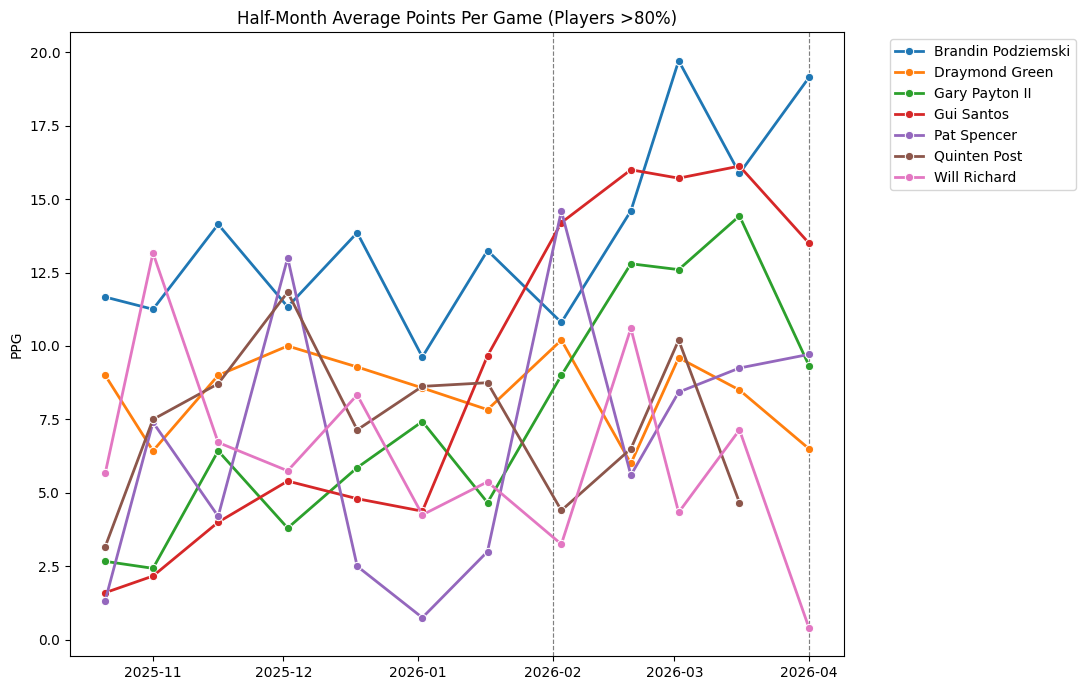

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# players >80%
players_over_80 = player_summary.loc[
    player_summary['pct_played_total'] > 80,
    'PLAYER_NAME'
].tolist()

# filter data
plot_df = player_games[
    player_games['PLAYER_NAME'].isin(players_over_80)
].copy()

plot_df['GAME_DATE'] = pd.to_datetime(plot_df['GAME_DATE'])

# create half-month bins
plot_df['Month'] = plot_df['GAME_DATE'].dt.to_period('M')

plot_df['Half'] = plot_df['GAME_DATE'].dt.day.apply(
    lambda x: '1H' if x <= 15 else '2H'
)

# combine into a time variable
plot_df['HalfMonth'] = (
    plot_df['Month'].astype(str) + '-' + plot_df['Half']
)

# convert to ordered datetime (for plotting)
plot_df['HalfMonthDate'] = plot_df.groupby('HalfMonth')['GAME_DATE'].transform('min')

# aggregate
halfmonth_df = (
    plot_df
    .groupby(['PLAYER_NAME', 'HalfMonthDate'])
    .agg({'PTS': 'mean'})
    .reset_index()
)

# plot
plt.figure(figsize=(11, 7))


plt.axvline(pd.to_datetime('2026-02-01'), linewidth=0.85, linestyle='--', color='gray')
plt.axvline(pd.to_datetime('2026-04-01'), linewidth=0.85, linestyle='--', color='gray')


sns.lineplot(
    data=halfmonth_df,
    x='HalfMonthDate',
    y='PTS',
    hue='PLAYER_NAME',
    marker='o',
    linewidth=2
)

plt.title('Half-Month Average Points Per Game (Players >80%)')
plt.xlabel('')
plt.ylabel('PPG')

plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('002_spaghetti_80pct_bimonthly.png', dpi=300, bbox_inches='tight')
plt.show()



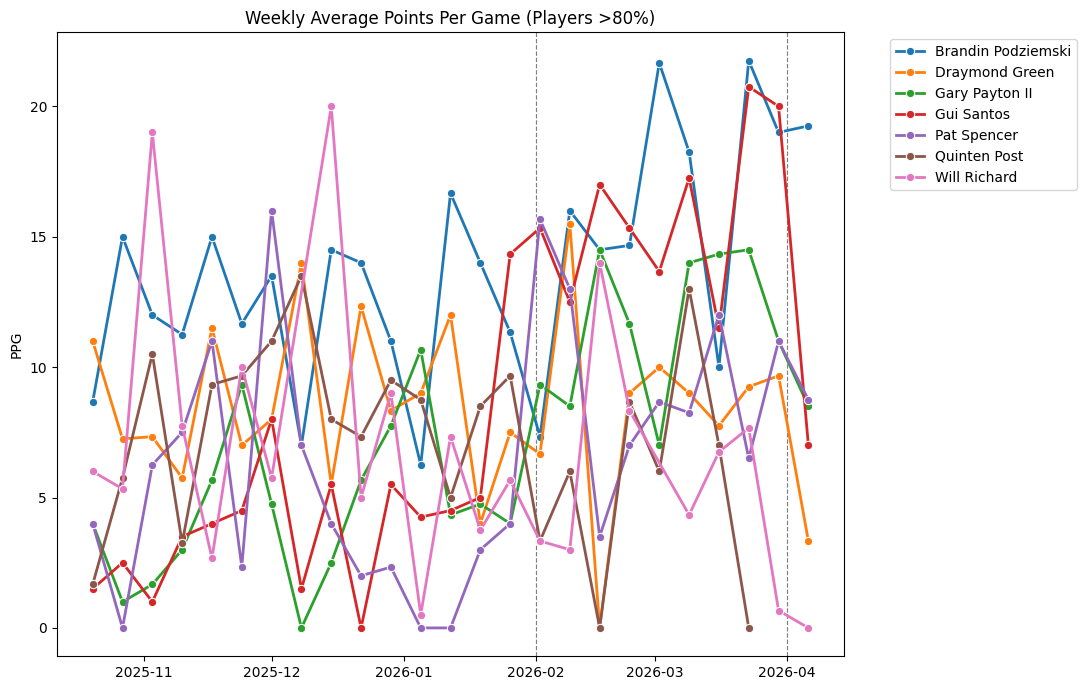

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# players >80%
players_over_80 = player_summary.loc[
    player_summary['pct_played_total'] > 80,
    'PLAYER_NAME'
].tolist()

# filter data
plot_df = player_games[
    player_games['PLAYER_NAME'].isin(players_over_80)
].copy()

plot_df['GAME_DATE'] = pd.to_datetime(plot_df['GAME_DATE'])

# create week variable (start of week)
plot_df['Week'] = plot_df['GAME_DATE'].dt.to_period('W').dt.start_time

# aggregate weekly averages
weekly_df = (
    plot_df
    .groupby(['PLAYER_NAME', 'Week'])
    .agg({'PTS': 'mean'})
    .reset_index()
)

# plot
plt.figure(figsize=(11, 7))

plt.axvline(pd.to_datetime('2026-02-01'), linewidth=0.85, linestyle='--', color='gray')
plt.axvline(pd.to_datetime('2026-04-01'), linewidth=0.85, linestyle='--', color='gray')

sns.lineplot(
    data=weekly_df,
    x='Week',
    y='PTS',
    hue='PLAYER_NAME',
    marker='o',
    linewidth=2
)

plt.title('Weekly Average Points Per Game (Players >80%)')
plt.xlabel('')
plt.ylabel('PPG')

plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('002_spaghetti_80pct_weekly.png', dpi=300, bbox_inches='tight')
plt.show()

## Interrupted Regression

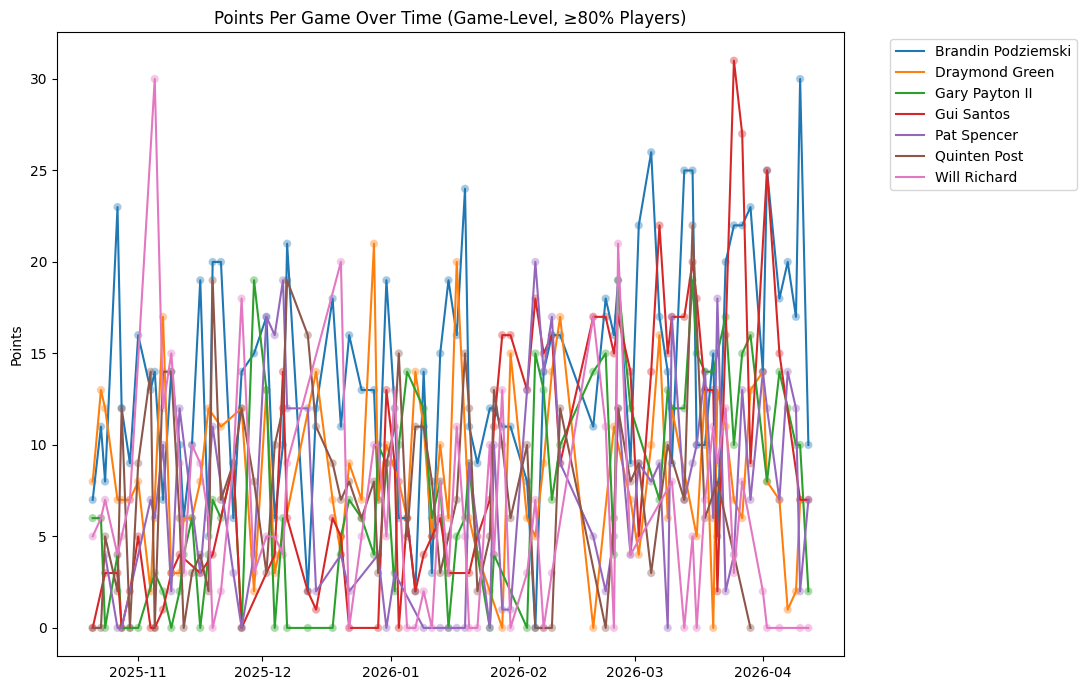

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# players >80%
players_over_80 = player_summary.loc[
    player_summary['pct_played_total'] > 80,
    'PLAYER_NAME'
].tolist()

# filter
plot_df = player_games[
    player_games['PLAYER_NAME'].isin(players_over_80)
].copy()

plot_df['GAME_DATE'] = pd.to_datetime(plot_df['GAME_DATE'])
plot_df = plot_df.sort_values(['PLAYER_NAME', 'GAME_DATE'])

# plot
plt.figure(figsize=(11, 7))

# raw points (light)
sns.scatterplot(
    data=plot_df,
    x='GAME_DATE',
    y='PTS',
    hue='PLAYER_NAME',
    alpha=0.4,
    legend=False
)

# trend lines (this is the key)
sns.lineplot(
    data=plot_df,
    x='GAME_DATE',
    y='PTS',
    hue='PLAYER_NAME',
    estimator=None,   # no averaging
    lw=1.5
)

plt.title('Points Per Game Over Time (Game-Level, ≥80% Players)')
plt.xlabel('')
plt.ylabel('Points')

plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('002_spaghetti_80pct_raw.png', dpi=300, bbox_inches='tight')
plt.show()

```
PTS ~ time 
    + time_post_injury 
    + time_post_return
```

In [38]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

df = player_games.copy()

df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
df = df.sort_values(['PLAYER_NAME', 'GAME_DATE'])

# restrict to >=80% players
players_over_80 = player_summary.loc[
    player_summary['pct_played_total'] > 80,
    'PLAYER_NAME'
].tolist()

df = df[df['PLAYER_NAME'].isin(players_over_80)].copy()

# time variable
df['time'] = (df['GAME_DATE'] - df['GAME_DATE'].min()).dt.days

# key dates
injury_date = pd.to_datetime('2026-01-30')
return_date = pd.to_datetime('2026-04-05')

# piecewise time variables
df['time_post_injury'] = np.maximum(
    0,
    (df['GAME_DATE'] - injury_date).dt.days
)

df['time_post_return'] = np.maximum(
    0,
    (df['GAME_DATE'] - return_date).dt.days
)

# run models per player and store slopes
results = {}
coef_list = []

for player, sub in df.groupby('PLAYER_NAME'):
    model = smf.ols(
        'PTS ~ time + time_post_injury + time_post_return',
        data=sub
    ).fit()
    
    results[player] = model
    
    params = model.params.to_dict()
    params['PLAYER_NAME'] = player
    
    # piecewise slopes
    params['slope_pre'] = params['time']
    params['slope_injury'] = params['time'] + params['time_post_injury']
    params['slope_post'] = (
        params['time']
        + params['time_post_injury']
        + params['time_post_return']
    )
    
    coef_list.append(params)

coef_df = pd.DataFrame(coef_list).set_index('PLAYER_NAME')

coef_df[['slope_pre', 'slope_injury', 'slope_post']]

,slope_pre,slope_injury,slope_post
PLAYER_NAME,,,
Brandin Podziemski,-0.007438,0.129669,-0.351843
Draymond Green,0.004147,0.000960,-1.136854
Gary Payton II,0.049747,0.122330,-1.625887
Gui Santos,0.091724,0.154343,-2.057797
Pat Spencer,-0.001760,0.074506,-0.618173
Quinten Post,0.014770,-0.028164,-0.028164
Will Richard,-0.033423,0.001923,-0.903919


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

df = player_games.copy()

df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
df = df.sort_values(['PLAYER_NAME', 'GAME_DATE'])

# restrict to >=80% players
players_over_80 = player_summary.loc[
    player_summary['pct_played_total'] > 80,
    'PLAYER_NAME'
].tolist()

df = df[df['PLAYER_NAME'].isin(players_over_80)].copy()

# key dates
injury_date = pd.to_datetime('2026-01-30')
return_date = pd.to_datetime('2026-04-05')

# time since first date in dataset
df['time'] = (df['GAME_DATE'] - df['GAME_DATE'].min()).dt.days

# piecewise time variables
df['time_post_injury'] = np.maximum(
    0,
    (df['GAME_DATE'] - injury_date).dt.days
)

df['time_post_return'] = np.maximum(
    0,
    (df['GAME_DATE'] - return_date).dt.days
)

# fit separate models and save fitted values
results = {}
pred_dfs = []
coef_list = []

for player, sub in df.groupby('PLAYER_NAME'):
    sub = sub.copy()

    model = smf.ols(
        'PTS ~ time + time_post_injury + time_post_return',
        data=sub
    ).fit()

    results[player] = model

    params = model.params.to_dict()
    params['PLAYER_NAME'] = player
    params['slope_pre'] = params['time']
    params['slope_injury'] = params['time'] + params['time_post_injury']
    params['slope_post'] = (
        params['time']
        + params['time_post_injury']
        + params['time_post_return']
    )
    coef_list.append(params)

    sub['fitted_pts'] = model.predict(sub)
    pred_dfs.append(sub)

coef_df = pd.DataFrame(coef_list).set_index('PLAYER_NAME')
pred_df = pd.concat(pred_dfs).sort_values(['PLAYER_NAME', 'GAME_DATE']).reset_index(drop=True)

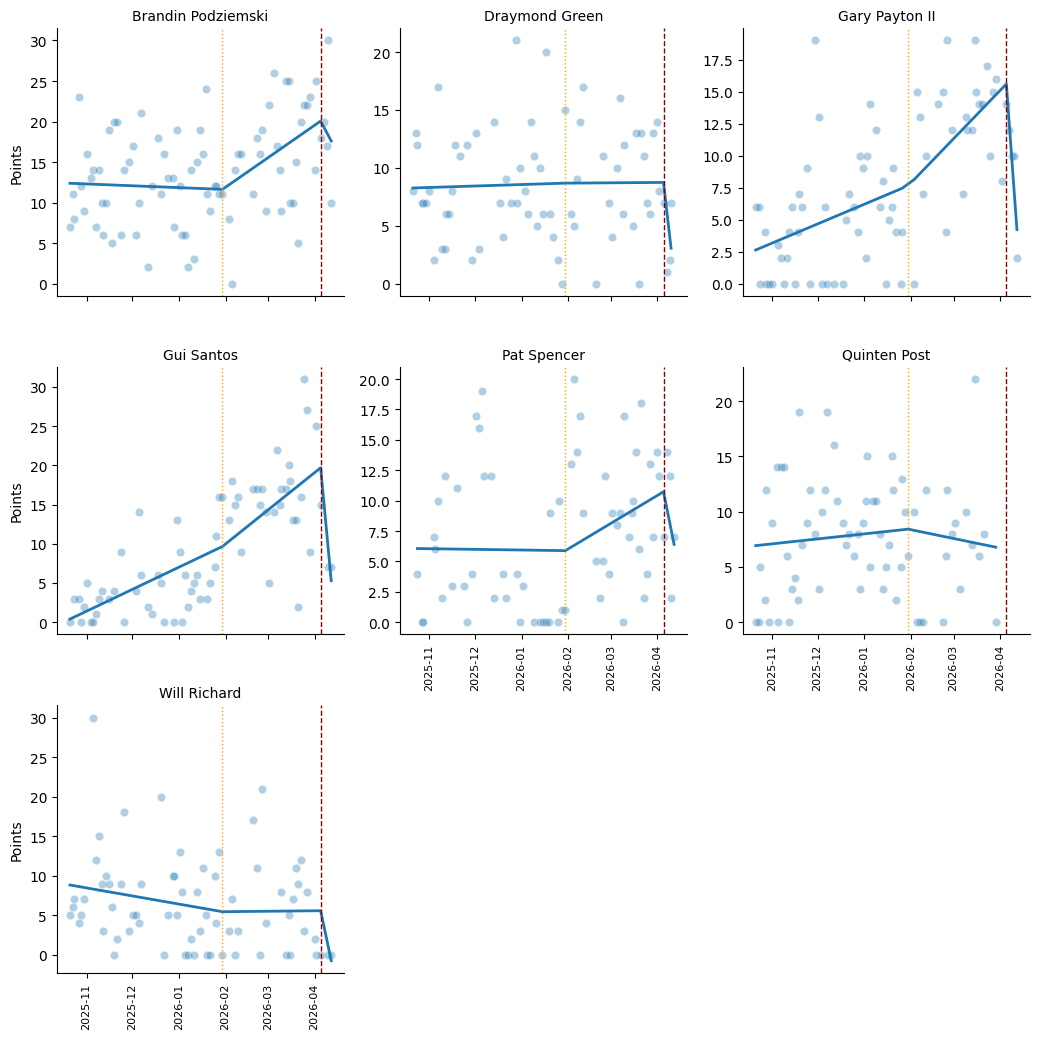

In [40]:
g = sns.FacetGrid(
    pred_df,
    col='PLAYER_NAME',
    col_wrap=3,
    height=3.5,
    sharey=False
)

# actual points
g.map_dataframe(
    sns.scatterplot,
    x='GAME_DATE',
    y='PTS',
    alpha=0.35
)

# fitted piecewise line
g.map_dataframe(
    sns.lineplot,
    x='GAME_DATE',
    y='fitted_pts',
    linewidth=2
)

for ax in g.axes.flatten():
    ax.axvline(injury_date, color='orange', linestyle=':', linewidth=1)
    ax.axvline(return_date, color='darkred', linestyle='--', linewidth=1)
    ax.tick_params(axis='x', rotation=90, labelsize=8)

g.set_titles('{col_name}')
g.set_axis_labels('', 'Points')

plt.tight_layout()
plt.savefig('002_interrupted_ts.png', dpi=300, bbox_inches='tight')
plt.show()

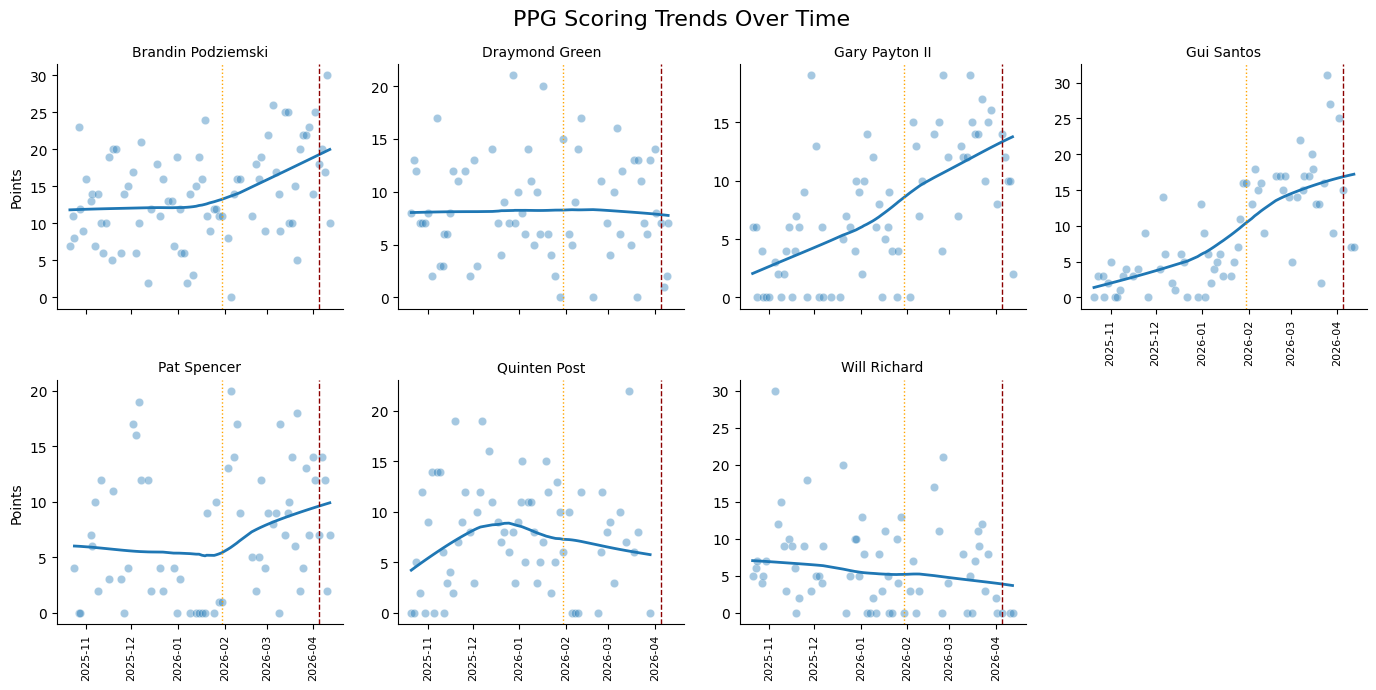

In [59]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

g = sns.FacetGrid(
    df,
    col='PLAYER_NAME',
    col_wrap=4,
    height=3.5,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x='GAME_DATE',
    y='PTS',
    alpha=0.4
)

for ax, (player, sub) in zip(g.axes.flatten(), df.groupby('PLAYER_NAME')):
    
    smoothed = lowess(
        sub['PTS'],
        sub['GAME_DATE'].astype('int64'),
        frac=0.7
    )
    
    ax.plot(
        pd.to_datetime(smoothed[:, 0]),
        smoothed[:, 1],
        linewidth=2
    )
    
    ax.axvline(injury_date, color='orange', linestyle=':', linewidth=1)
    ax.axvline(return_date, color='darkred', linestyle='--', linewidth=1)

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=90, labelsize=8)

g.set_titles('{col_name}')
g.set_axis_labels('', 'Points')

g.fig.suptitle('PPG Scoring Trends Over Time', fontsize=16)
g.fig.subplots_adjust(top=0.88)

plt.tight_layout()
plt.savefig('002_loess_smooth.png', dpi=300, bbox_inches='tight')
plt.show()

## Rolling % W/L

In [42]:
from nba_api.stats.endpoints import leaguegamelog
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# get ALL team game logs
gamelog = leaguegamelog.LeagueGameLog(
    season='2025-26',
    player_or_team_abbreviation='T'
).get_data_frames()[0]

df_team = gamelog.copy()

# filter Warriors
df_team = df_team[df_team['TEAM_ID'] == 1610612744]

df_team['GAME_DATE'] = pd.to_datetime(df_team['GAME_DATE'])
df_team = df_team.sort_values('GAME_DATE')

# win indicator
df_team['win'] = (df_team['WL'] == 'W').astype(int)

# rolling win %
df_team['win_pct_10'] = df_team['win'].rolling(10, min_periods=1).mean()

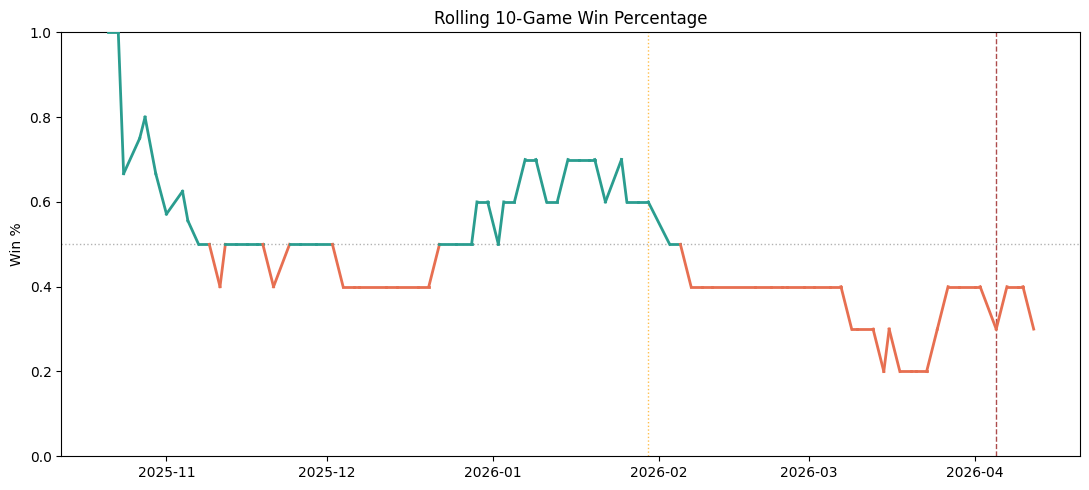

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

# prep
x = df_team['GAME_DATE'].reset_index(drop=True)
y = df_team['win_pct_10'].reset_index(drop=True)

threshold = 0.5

green = '#2a9d8f'
red = '#e76f51'

plt.figure(figsize=(11, 5))

# --- reference lines (drawn behind) ---
plt.axhline(threshold, color='gray', linestyle=':', linewidth=1, alpha=0.6, zorder=1)

plt.axvline(injury_date, color='orange', linestyle=':', linewidth=1, alpha=0.7, zorder=1)
plt.axvline(return_date, color='darkred', linestyle='--', linewidth=1, alpha=0.7, zorder=1)

# --- colored segments ---
for i in range(len(x) - 1):
    x1, x2 = x.iloc[i], x.iloc[i + 1]
    y1, y2 = y.iloc[i], y.iloc[i + 1]

    # same side of threshold
    if (y1 >= threshold and y2 >= threshold):
        plt.plot([x1, x2], [y1, y2], color=green, linewidth=2, zorder=3)

    elif (y1 < threshold and y2 < threshold):
        plt.plot([x1, x2], [y1, y2], color=red, linewidth=2, zorder=3)

    else:
        # crossing: interpolate exact crossing point
        frac = (threshold - y1) / (y2 - y1)
        x_cross = x1 + (x2 - x1) * frac

        # first segment
        plt.plot(
            [x1, x_cross],
            [y1, threshold],
            color=green if y1 >= threshold else red,
            linewidth=2,
            zorder=3
        )

        # second segment
        plt.plot(
            [x_cross, x2],
            [threshold, y2],
            color=green if y2 >= threshold else red,
            linewidth=2,
            zorder=3
        )

# --- labels ---
plt.title('Rolling 10-Game Win Percentage')
plt.xlabel('')
plt.ylabel('Win %')

plt.ylim(0, 1)

plt.tight_layout()
plt.savefig('002_rolling_10avg.png', dpi=300, bbox_inches='tight')
plt.show()

# OLD
We are making separate models here because each player is considered as a sample. How did each player respond? Not what is the average effect across the players during the time periods.

In [44]:
import pandas as pd
import statsmodels.formula.api as smf

df = player_games.copy()

df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
df = df.sort_values(['PLAYER_NAME', 'GAME_DATE'])

# time variable
df['time'] = (df['GAME_DATE'] - df['GAME_DATE'].min()).dt.days

# key dates
injury_date = pd.to_datetime('2026-01-30')
return_date = pd.to_datetime('2026-04-05')

df['post_injury'] = (df['GAME_DATE'] >= injury_date).astype(int)
df['post_return'] = (df['GAME_DATE'] >= return_date).astype(int)

# restrict to >=80% players
players_over_80 = player_summary.loc[
    player_summary['pct_played_total'] > 80,
    'PLAYER_NAME'
].tolist()

df = df[df['PLAYER_NAME'].isin(players_over_80)]

# run separate regressions and save predictions
results = {}
coef_list = []
pred_dfs = []

for player, sub in df.groupby('PLAYER_NAME'):
    sub = sub.copy()
    
    model = smf.ols(
        'PTS ~ time + post_injury + post_return',
        data=sub
    ).fit()
    
    results[player] = model
    
    temp = model.params.to_dict()
    temp['PLAYER_NAME'] = player
    coef_list.append(temp)
    
    sub['predicted_pts'] = model.predict(sub)
    pred_dfs.append(sub)

coef_df = pd.DataFrame(coef_list).set_index('PLAYER_NAME')

pred_df = pd.concat(pred_dfs).sort_values(['PLAYER_NAME', 'GAME_DATE']).reset_index(drop=True)

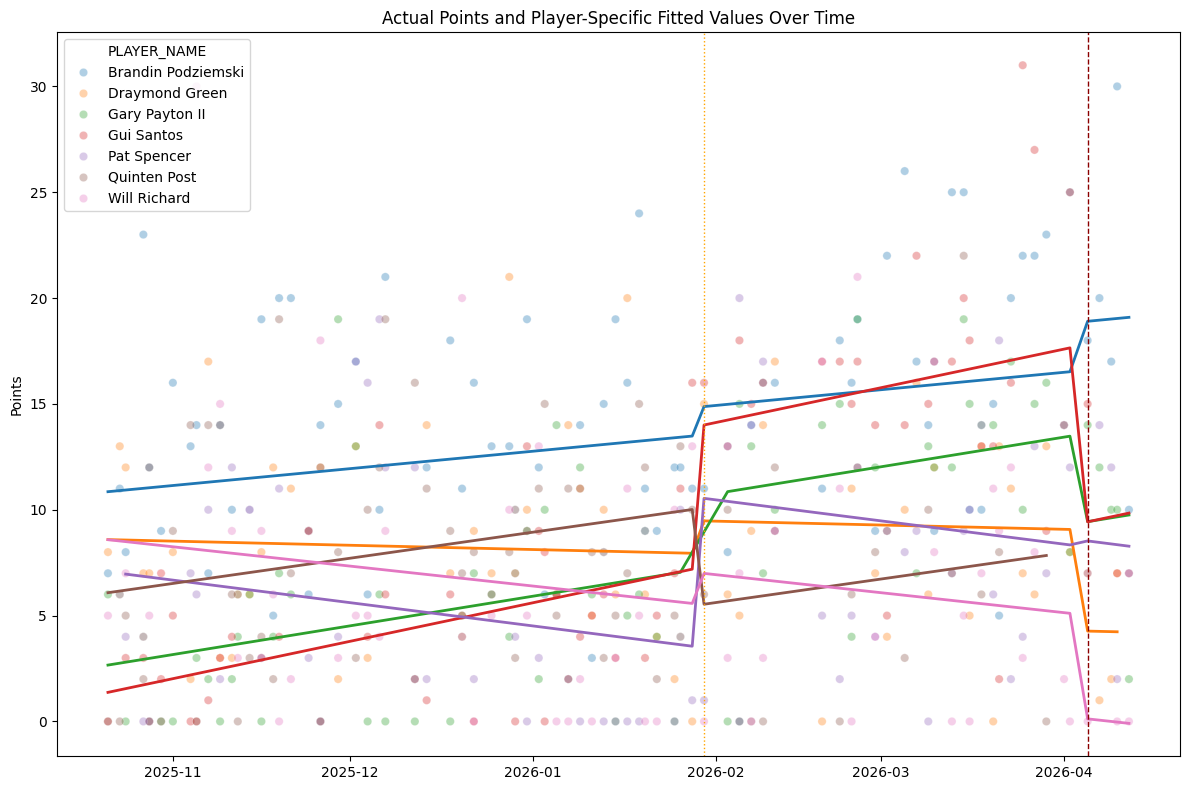

In [45]:
plt.figure(figsize=(12, 8))

# actual points
sns.scatterplot(
    data=pred_df,
    x='GAME_DATE',
    y='PTS',
    hue='PLAYER_NAME',
    alpha=0.35,
    legend=True
)

# predicted lines
sns.lineplot(
    data=pred_df,
    x='GAME_DATE',
    y='predicted_pts',
    hue='PLAYER_NAME',
    linewidth=2,
    legend=False
)

# optional event lines
plt.axvline(injury_date, color='orange', linestyle=':', linewidth=1)
plt.axvline(return_date, color='darkred', linestyle='--', linewidth=1)

plt.title('Actual Points and Player-Specific Fitted Values Over Time')
plt.xlabel('')
plt.ylabel('Points')

plt.tight_layout()
plt.show()

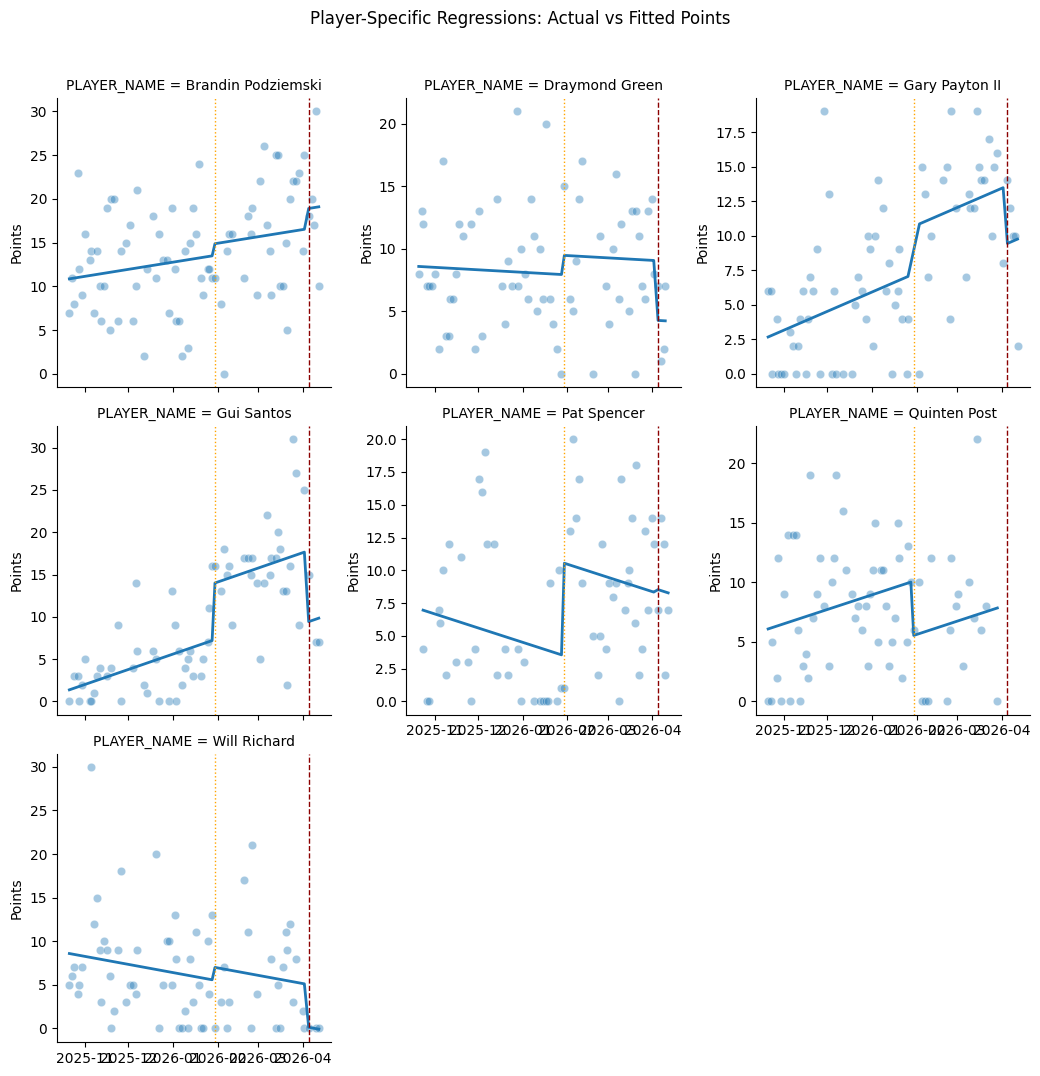

In [46]:
g = sns.FacetGrid(
    pred_df,
    col='PLAYER_NAME',
    col_wrap=3,
    height=3.5,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x='GAME_DATE',
    y='PTS',
    alpha=0.4
)

g.map_dataframe(
    sns.lineplot,
    x='GAME_DATE',
    y='predicted_pts',
    linewidth=2
)

for ax in g.axes.flatten():
    ax.axvline(injury_date, color='orange', linestyle=':', linewidth=1)
    ax.axvline(return_date, color='darkred', linestyle='--', linewidth=1)
    ax.set_xlabel('')
    ax.set_ylabel('Points')

g.fig.suptitle('Player-Specific Regressions: Actual vs Fitted Points', y=1.02)
plt.tight_layout()
plt.show()

## Modeling player share of points

In [47]:
import pandas as pd
import statsmodels.formula.api as smf

# team total points per game
team_pts = (
    player_games
    .groupby('GAME_ID')['PTS']
    .sum()
    .reset_index()
    .rename(columns={'PTS': 'TEAM_PTS'})
)

# merge team totals back to player-game data
df = player_games.merge(team_pts, on='GAME_ID', how='left').copy()

# restrict to players who played more than 80% of total games
players_over_80 = player_summary.loc[
    player_summary['pct_played_total'] > 80,
    'PLAYER_NAME'
].tolist()

df = df[df['PLAYER_NAME'].isin(players_over_80)].copy()

# clean date
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])

# share of team points in each game
df['share'] = df['PTS'] / df['TEAM_PTS']

# define period
df['Period'] = 'Pre'
df.loc[df['GAME_DATE'] >= pd.to_datetime('2026-01-30'), 'Period'] = 'Injury'
df.loc[df['GAME_DATE'] >= pd.to_datetime('2026-04-05'), 'Period'] = 'Post'

# enforce period order
df['Period'] = pd.Categorical(
    df['Period'],
    categories=['Pre', 'Injury', 'Post'],
    ordered=True
)

# model
interaction_model = smf.ols(
    'share ~ C(PLAYER_NAME) * C(Period)',
    data=df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  share   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     12.57
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.54e-31
Time:                        16:13:18   Log-Likelihood:                 812.98
No. Observations:                 493   AIC:                            -1586.
Df Residuals:                     473   BIC:                            -1502.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

## Lowess

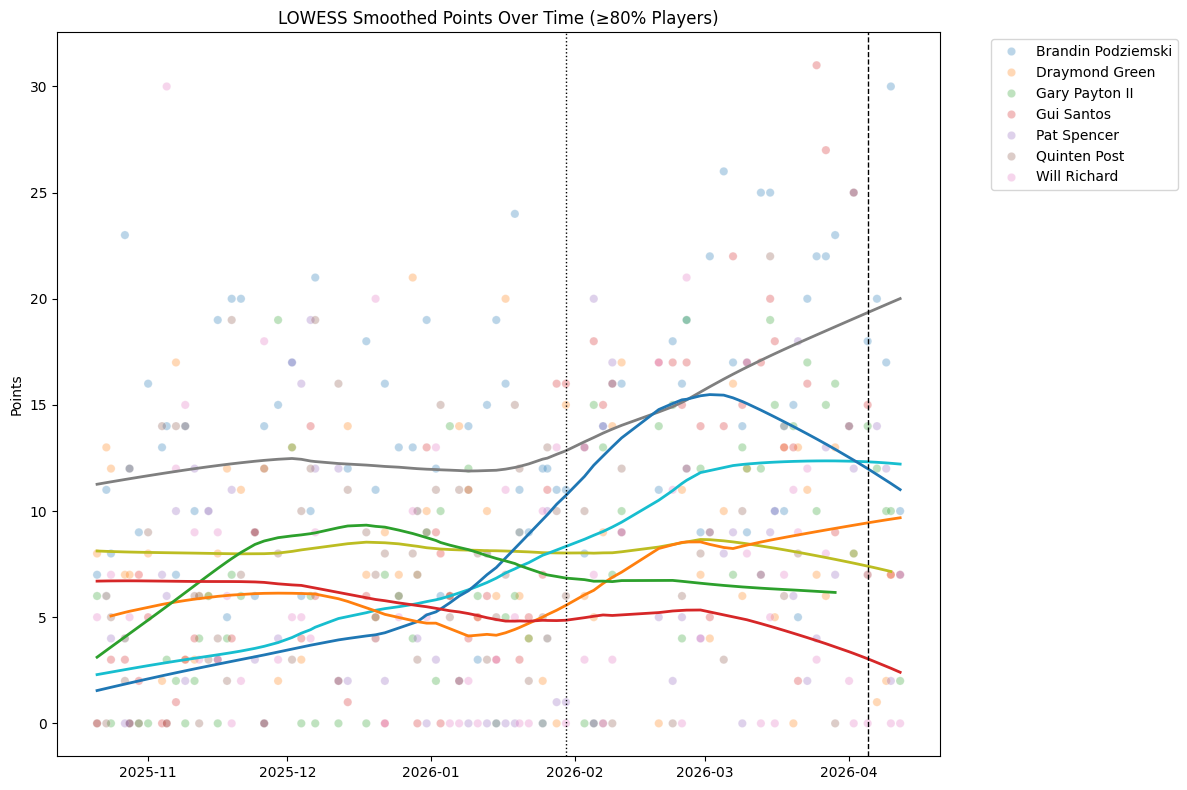

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = player_games.copy()

df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
df = df.sort_values(['PLAYER_NAME', 'GAME_DATE'])

# restrict to >=80% players
players_over_80 = player_summary.loc[
    player_summary['pct_played_total'] > 80,
    'PLAYER_NAME'
].tolist()

df = df[df['PLAYER_NAME'].isin(players_over_80)].copy()

# plot
plt.figure(figsize=(12, 8))

# scatter (light)
sns.scatterplot(
    data=df,
    x='GAME_DATE',
    y='PTS',
    hue='PLAYER_NAME',
    alpha=0.3,
    legend=True
)

# LOWESS smooth (this is the key)
sns.lineplot(
    data=df,
    x='GAME_DATE',
    y='PTS',
    hue='PLAYER_NAME',
    estimator=None,
    lw=0,  # hide default lines
    legend=False
)

# apply LOWESS per player manually
from statsmodels.nonparametric.smoothers_lowess import lowess

for player, sub in df.groupby('PLAYER_NAME'):
    smoothed = lowess(
        sub['PTS'],
        sub['GAME_DATE'].astype('int64'),  # convert to numeric
        frac=0.5  # smoothing strength
    )
    
    plt.plot(
        pd.to_datetime(smoothed[:, 0]),
        smoothed[:, 1],
        linewidth=2
    )

# event lines
injury_date = pd.to_datetime('2026-01-30')
return_date = pd.to_datetime('2026-04-05')

plt.axvline(injury_date, color='black', linestyle=':', linewidth=1)
plt.axvline(return_date, color='black', linestyle='--', linewidth=1)

plt.title('LOWESS Smoothed Points Over Time (≥80% Players)')
plt.xlabel('')
plt.ylabel('Points')

plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

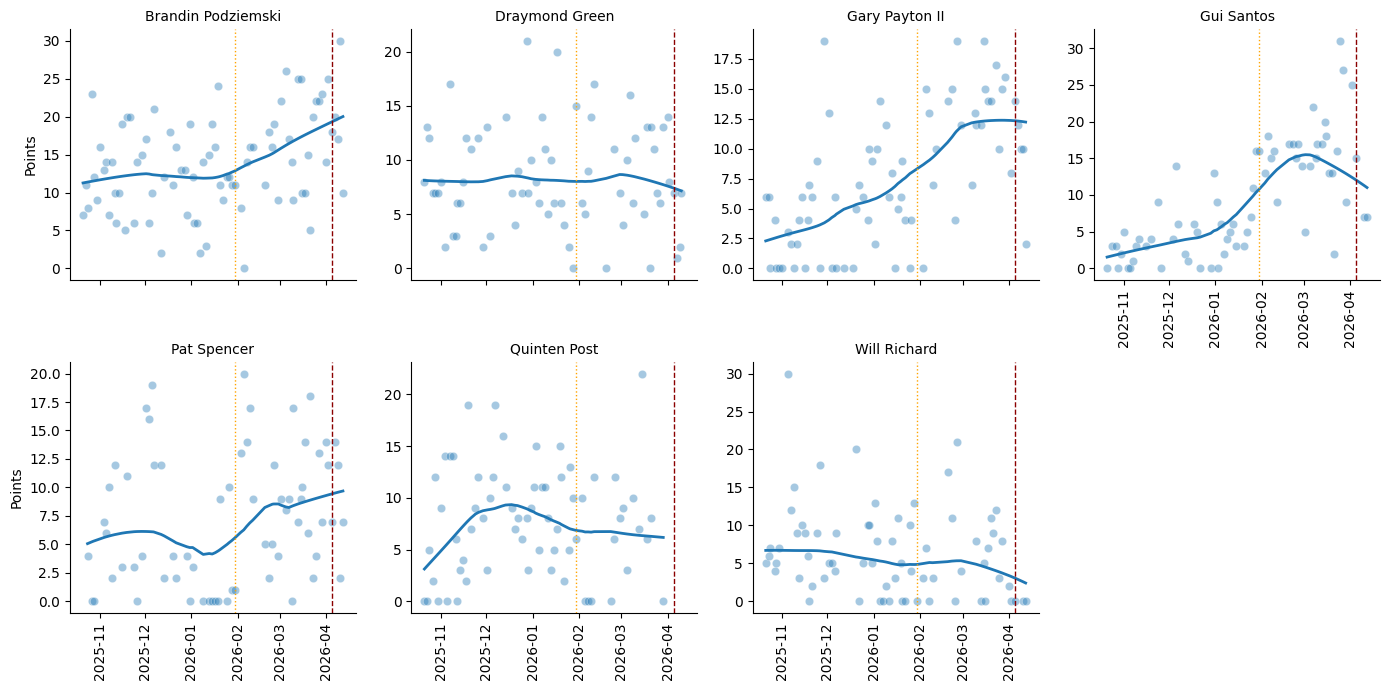

In [49]:
g = sns.FacetGrid(
    df,
    col='PLAYER_NAME',
    col_wrap=4,
    height=3.5,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x='GAME_DATE',
    y='PTS',
    alpha=0.4
)

for ax, (player, sub) in zip(g.axes.flatten(), df.groupby('PLAYER_NAME')):
    smoothed = lowess(
        sub['PTS'],
        sub['GAME_DATE'].astype('int64'),
        frac=0.5
    )
    
    ax.plot(
        pd.to_datetime(smoothed[:, 0]),
        smoothed[:, 1],
        linewidth=2
    )
    
    ax.axvline(injury_date, color='orange', linestyle=':', linewidth=1)
    ax.axvline(return_date, color='darkred', linestyle='--', linewidth=1)

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=90)

g.set_titles('{col_name}')
g.set_axis_labels('', 'Points')

plt.tight_layout()
plt.show()